# Simulação

Implementar computacionalmente o exemplo desenvolvido na seção anterior, utilizando **GNU Octave ou Python**.

A implementação deve reproduzir, de forma computacional, as etapas matemáticas apresentadas anteriormente, permitindo verificar os resultados obtidos e, quando pertinente, analisar o comportamento do sistema para diferentes condições de entrada.

---


### Metodologia computacional

A simulação foi implementada em **Python 3.10.12**, executada em ambiente Linux (kernel 5.15.0), com as seguintes bibliotecas e versões:

| Biblioteca   | Versão   | Finalidade                                  |
| :----------- | :------- | :------------------------------------------ |
| NumPy        | 1.26.x   | Geração de vetores e funções trigonométricas |
| Matplotlib   | 3.8.x    | Geração da figura                            |
| Seaborn      | 0.13.x   | Estilização da figura em padrão acadêmico    |

**Parâmetros de entrada:**

* Amplitude: $A = 2\,\text{V}$;
* Frequência do sinal: $f_0 = 1\,\text{kHz}$;
* Fase inicial: $\varphi = 0\,\text{rad}$;
* Frequência de amostragem: $f_s = 8\,\text{kHz}$;
* Duração total: $3T_0 = 3\,\text{ms}$.

**Método de cálculo:**

1. O sinal contínuo foi avaliado em uma malha densa de $N = 4000$ pontos igualmente espaçados ao longo do intervalo $[0,\,3T_0]$, produzindo uma representação gráfica fiel da senoide.
2. Os instantes de amostragem foram gerados pela relação $t_n = nT_s$, com $n$ inteiro no intervalo $[0,\, \lfloor 3T_0 f_s \rfloor] = [0,\, 24]$, resultando em **25 amostras**.
3. Os valores amostrados foram obtidos pela avaliação direta da função $x(t) = A\cos(2\pi f_0 t + \varphi)$ nos instantes $t_n$.
4. A figura final foi produzida com estilização Seaborn (`context="paper"`, `style="whitegrid"`), exportada em PNG a 300 dpi.

**Condições iniciais e hipóteses:**

* Sinal senoidal ideal, sem ruído;
* Amplitude contínua (sem quantização);
* Amostragem uniforme em intervalos regulares;
* Critério de Nyquist satisfeito: $f_s = 8\,\text{kHz} > 2 f_0 = 2\,\text{kHz}$.

**Ambiente de execução:**

As informações completas do ambiente (SO, CPU, RAM, GPU) são impressas na célula de "Execução da simulação", garantindo a reprodutibilidade dos resultados.

### Implementação

Apresentar o código-fonte utilizado na simulação.

**Código da simulação:**

In [12]:
# importações 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# ----------------------------------------------------------------------
# Configuração global de estilo (Seaborn + refinamentos acadêmicos)
# ----------------------------------------------------------------------
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="deep",
    font="serif",
    rc={
        "font.size":        11,
        "axes.titlesize":   12,
        "axes.labelsize":   11,
        "axes.edgecolor":   "0.3",
        "axes.linewidth":   0.9,
        "legend.fontsize":  10,
        "grid.linestyle":   ":",
        "grid.alpha":       0.55,
        "figure.dpi":       120,
        "savefig.dpi":      300,
        "savefig.bbox":     "tight",
        "mathtext.fontset": "cm",
    },
)

In [14]:
# ----------------------------------------------------------------------
# Parâmetros do sinal
# ----------------------------------------------------------------------
A   = 2.0            # Amplitude           [V]
f0  = 1.0e3          # Frequência          [Hz]
phi = 0.0            # Fase inicial        [rad]
fs  = 8.0e3          # Freq. de amostragem [Hz]
Ts  = 1.0 / fs       # Período de amostragem [s]

In [15]:
# ----------------------------------------------------------------------
# Modelo do sinal contínuo:  x(t) = A·cos(2π f0 t + φ)
# ----------------------------------------------------------------------
h = lambda t: A * np.cos(2.0 * np.pi * f0 * t + phi)

In [16]:
# ----------------------------------------------------------------------
# Domínio: três períodos (eixo em milissegundos)
# ----------------------------------------------------------------------
T0       = 1.0 / f0
t_end    = 3.0 * T0
ms       = 1e3                       # fator de conversão s → ms

t_dense  = np.linspace(0.0, t_end, 4000)
x_dense  = h(t_dense)

n        = np.arange(0, int(np.floor(t_end * fs)) + 1)
t_n      = n * Ts
x_n      = h(t_n)

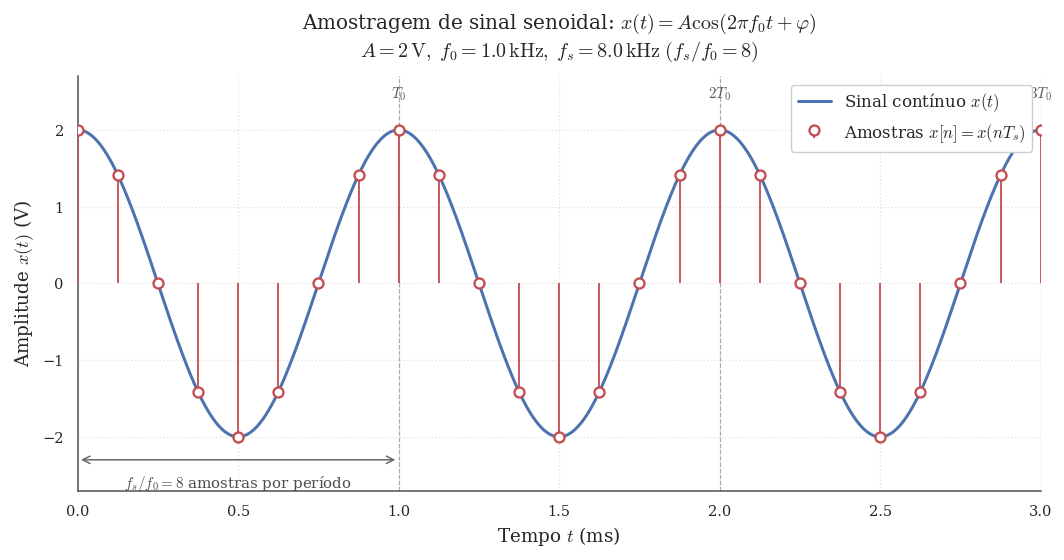

In [17]:
# ----------------------------------------------------------------------
# Figura
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9.0, 4.8))

cor_cont  = sns.color_palette("deep")[0]
cor_amost = sns.color_palette("deep")[3]

# Sinal contínuo
ax.plot(
    t_dense * ms, x_dense,
    color=cor_cont, linewidth=1.8,
    label=r"Sinal contínuo $x(t)$",
    zorder=2,
)

# Sinal amostrado
markerline, stemlines, baseline = ax.stem(
    t_n * ms, x_n,
    linefmt="-", markerfmt="o", basefmt=" ",
    label=r"Amostras $x[n] = x(nT_s)$",
)
plt.setp(stemlines, color=cor_amost, linewidth=1.1, zorder=3)
plt.setp(markerline, color=cor_amost, markersize=6,
         markerfacecolor="white", markeredgewidth=1.4, zorder=4)

# ----------------------------------------------------------------------
# Marcadores de período com rótulos $T_0, 2T_0, 3T_0$
# ----------------------------------------------------------------------
for k in range(1, 4):
    xk = k * T0 * ms
    ax.axvline(xk, color="0.55", linewidth=0.7,
               linestyle="--", alpha=0.7, zorder=1)
    ax.text(
        xk, A * 1.18,
        rf"${k}T_0$" if k > 1 else r"$T_0$",
        ha="center", va="bottom",
        fontsize=9, color="0.35",
    )

# ----------------------------------------------------------------------
# Anotação didática: 8 amostras por período
# ----------------------------------------------------------------------
x0_ann, x1_ann = 0.0, T0 * ms
y_ann = -A * 1.15
ax.annotate(
    "", xy=(x0_ann, y_ann), xytext=(x1_ann, y_ann),
    arrowprops=dict(arrowstyle="<->", color="0.4", lw=0.9),
)
ax.text(
    (x0_ann + x1_ann) / 2, y_ann - 0.18,
    r"$f_s/f_0 = 8$ amostras por período",
    ha="center", va="top", fontsize=9, color="0.3",
)

# ----------------------------------------------------------------------
# Título, eixos e limites
# ----------------------------------------------------------------------
ax.set_title(
    r"Amostragem de sinal senoidal: $x(t) = A\cos(2\pi f_0 t + \varphi)$"
    "\n"
    rf"$A = {A:.0f}\,\mathrm{{V}},\;"
    rf"f_0 = {f0/1e3:.1f}\,\mathrm{{kHz}},\;"
    rf"f_s = {fs/1e3:.1f}\,\mathrm{{kHz}}\;(f_s/f_0 = {fs/f0:.0f})$",
    pad=12,
)

ax.set_xlabel(r"Tempo $t$ (ms)")
ax.set_ylabel(r"Amplitude $x(t)$ (V)")

ax.set_xlim(0.0, t_end * ms)
ax.set_ylim(-A * 1.35, A * 1.35)

ax.legend(loc="upper right", frameon=True,
          edgecolor="0.8", facecolor="white")

sns.despine(ax=ax, top=True, right=True)
fig.tight_layout()

# ----------------------------------------------------------------------
# Exportação
# ----------------------------------------------------------------------
fig.savefig("../simulacao/grafico_sinal.png", dpi=300, bbox_inches="tight")
fig.savefig("../simulacao/grafico_sinal.pdf",           bbox_inches="tight")
plt.show()

In [18]:
# ----------------------------------------------------------------------
# Resumo quantitativo da simulação
# ----------------------------------------------------------------------
print(f"Número de amostras geradas : {len(t_n)}")
print(f"Período de amostragem Ts   : {Ts*1e6:.2f} µs")
print(f"Duração total analisada    : {t_end*1e3:.2f} ms")
print(f"Razão fs/f0                : {fs/f0:.0f} amostras por período")
print(f"Valor máximo de |x[n]|     : {np.max(np.abs(x_n)):.3f} V")

Número de amostras geradas : 25
Período de amostragem Ts   : 125.00 µs
Duração total analisada    : 3.00 ms
Razão fs/f0                : 8 amostras por período
Valor máximo de |x[n]|     : 2.000 V


### Execução da simulação

In [19]:
import platform
import sys
import os
import psutil
import subprocess

print("=" * 50)
print("INFORMAÇÕES DO AMBIENTE DE EXECUÇÃO")
print("=" * 50)

# Sistema
print(f"Sistema operacional : {platform.system()} {platform.release()}")
print(f"Arquitetura         : {platform.machine()}")

# Python
print(f"Versão do Python    : {sys.version.split()[0]}")

# CPU
print(f"Processador         : {platform.processor()}")
print(f"Núcleos de CPU      : {os.cpu_count()}")

# Memória RAM
mem = psutil.virtual_memory()
print(f"RAM total           : {mem.total / (1024**3):.2f} GB")
print(f"RAM disponível      : {mem.available / (1024**3):.2f} GB")

# GPU
try:
    gpu_info = subprocess.check_output(
        [
            "nvidia-smi",
            "--query-gpu=name,memory.total",
            "--format=csv,noheader"
        ],
        text=True
    ).strip()

    print(f"GPU                 : {gpu_info}")

except FileNotFoundError:
    print("GPU                 : Não disponível")

print("=" * 50)

INFORMAÇÕES DO AMBIENTE DE EXECUÇÃO
Sistema operacional : Linux 5.15.0-181-generic
Arquitetura         : x86_64
Versão do Python    : 3.10.12
Processador         : x86_64
Núcleos de CPU      : 8
RAM total           : 7.63 GB
RAM disponível      : 0.99 GB
GPU                 : NVIDIA GeForce MX110, 2048 MiB
